# Sentence Transformer 10M-Row Batch Inference Benchmark

Benchmarks `mv.run_batch()` with 10 million rows of sentence embedding on GPU.

**Prerequisites:**
- `pip install snowflake-ml-python sentence-transformers torch matplotlib pandas`
- A Snowflake connection configured in `~/.snowflake/connections.toml`
- An image repository accessible to your account (e.g. `MY_DB.PUBLIC.IMAGES`)
- Permission to create databases, compute pools, and warehouses

**Usage:** Fill in the User Configuration cell below, then Run All.

In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# ║  USER CONFIGURATION — fill these in before running         ║
# ╚════════════════════════════════════════════════════════════╝
CONNECTION_NAME = "<connection>"         # Snowflake connection name (from ~/.snowflake/connections.toml)
DB_NAME = "ST_BENCHMARK"                # Database to create/use for this benchmark
WAREHOUSE_SIZE = "4X-LARGE"             # Warehouse size for data generation
IMAGE_REPO = "<db>.<schema>.<repo>"     # Image repository for SPCS containers
EVENT_TABLE = "<db>.<schema>.<table>"   # Event table for platform metrics (set to None to skip metrics)

# ╔════════════════════════════════════════════════════════════╗
# ║  BENCHMARK DEFAULTS — change only to explore alternatives  ║
# ╚════════════════════════════════════════════════════════════╝
NUM_NODES = 2
INSTANCE_FAMILY = "GPU_NV_S"
NUM_WORKERS = 2
MAX_BATCH_ROWS = 256
REPLICAS = 2
FUNCTION_NAME = "encode"
INPUT_ROWS = 10_000_000
GPU_REQUESTS = "1"                      # GPUs per worker
REPEAT = 3
WARMUP_ROW_COUNT = 1_000

MODEL_ID = "all-MiniLM-L6-v2"          # HuggingFace model to download
MODEL_NAME = "all_minilm_l6_v2"
MODEL_VERSION = "V1"

In [5]:
assert IMAGE_REPO != "<db>.<schema>.<repo>", "Set IMAGE_REPO to your image repository"
if EVENT_TABLE == "<db>.<schema>.<table>":
    EVENT_TABLE = None
    print("EVENT_TABLE not configured -- platform metrics will be skipped.")

WAREHOUSE_NAME = f"{DB_NAME}_WH"
POOL_PREFIX = "BENCHMARK_POOL_ST"

print(f"Environment: {CONNECTION_NAME} / {DB_NAME}")
print(f"Benchmark: {INPUT_ROWS:,} rows, {REPLICAS} replicas, {NUM_WORKERS} workers, batch={MAX_BATCH_ROWS:,}")
print(f"Compute: {NUM_NODES}x {INSTANCE_FAMILY}")
print(f"Model: {MODEL_NAME}/{MODEL_VERSION}")
print(f"Repeat: {REPEAT}x")

Environment: prod3 / ST_BENCHMARK
Benchmark: 10,000,000 rows, 2 replicas, 2 workers, batch=256
Compute: 2x GPU_NV_S
Model: all_minilm_l6_v2/V1
Repeat: 1x


## Session + Setup

In [6]:
from snowflake.snowpark import Session

session = Session.builder.configs({"connection_name": CONNECTION_NAME}).create()
print(f"Connected: {session.get_current_account()}")

session.sql(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}").collect()
session.sql(f"CREATE SCHEMA IF NOT EXISTS {DB_NAME}.PUBLIC").collect()
session.sql(f"USE DATABASE {DB_NAME}").collect()
session.sql(f"USE SCHEMA PUBLIC").collect()
session.sql(f"CREATE STAGE IF NOT EXISTS BENCHMARK_STAGE ENCRYPTION = (TYPE = 'SNOWFLAKE_SSE')").collect()
session.sql(
    f"CREATE WAREHOUSE IF NOT EXISTS {WAREHOUSE_NAME} WITH WAREHOUSE_SIZE='{WAREHOUSE_SIZE}' AUTO_SUSPEND=60"
).collect()

print("Environment resources ready.")

# --- Download and register Sentence Transformer model ---
import pandas as pd
from snowflake.ml.registry import registry

reg = registry.Registry(session=session, database_name=DB_NAME, schema_name="PUBLIC")

try:
    mv = reg.get_model(MODEL_NAME).version(MODEL_VERSION)
    print(f"Model already registered: {MODEL_NAME}/{MODEL_VERSION}")
except Exception:
    import os
    import tempfile

    import sentence_transformers

    print(f"Downloading {MODEL_ID}...")
    cache_dir = tempfile.mkdtemp(prefix="st_cache_")
    prev_cache = os.environ.get("SENTENCE_TRANSFORMERS_HOME")
    os.environ["SENTENCE_TRANSFORMERS_HOME"] = cache_dir
    try:
        model = sentence_transformers.SentenceTransformer(MODEL_ID)
    finally:
        if prev_cache is not None:
            os.environ["SENTENCE_TRANSFORMERS_HOME"] = prev_cache
        else:
            os.environ.pop("SENTENCE_TRANSFORMERS_HOME", None)

    sample_input = pd.DataFrame({
        "SENTENCE": [
            "This is a sample sentence for model signature inference.",
            "Another example sentence to establish the input schema.",
            "A third sentence to round out the sample data.",
        ]
    })

    mv = reg.log_model(
        model,
        model_name=MODEL_NAME,
        version_name=MODEL_VERSION,
        pip_requirements=["sentence-transformers", "torch==2.6.0"],
        options={"enable_explainability": False, "cuda_version": "12.4", "embed_local_ml_library": True},
        target_platforms=["SNOWPARK_CONTAINER_SERVICES"],
    )
    print(f"Registered: {MODEL_NAME}/{MODEL_VERSION}")

# --- Generate input data ---
SENTENCE_TEMPLATES = [
    "Machine learning models require diverse training data for optimal performance across domains.",
    "Natural language processing enables computers to understand and generate human text.",
    "Deep learning has transformed how we approach complex pattern recognition problems.",
    "Artificial intelligence continues to evolve rapidly with new architectures and techniques.",
    "Text embeddings capture semantic relationships between words and phrases effectively.",
    "Sentence transformers excel at computing dense vector representations of text.",
    "Benchmark testing ensures reliable and reproducible performance metrics across runs.",
    "Concurrent processing improves system throughput significantly for batch workloads.",
    "Latency optimization remains crucial for delivering responsive user experiences.",
    "Transfer learning allows models pretrained on large corpora to generalize to new tasks.",
    "The quick brown fox jumps over the lazy dog near the riverbank.",
    "Distributed computing frameworks enable processing of massive datasets in parallel.",
    "Transformer architectures use self-attention mechanisms to capture long-range dependencies in sequences.",
    "Snowflake provides a cloud-native data platform for analytics and machine learning workloads.",
    "Batch inference pipelines process large volumes of data efficiently using horizontal scaling.",
    "Embedding models convert unstructured text into fixed-dimensional numerical vectors for downstream tasks.",
    "Cosine similarity measures the angular distance between two vectors in high-dimensional space.",
    "Information retrieval systems rank documents by relevance to a user query.",
    "Tokenization splits raw text into subword units that neural networks can process.",
    "Dimensionality reduction techniques like PCA help visualize high-dimensional embedding spaces.",
    "Contrastive learning trains models to distinguish between similar and dissimilar pairs of examples.",
    "Knowledge distillation compresses large teacher models into smaller student models with minimal accuracy loss.",
    "Pooling strategies aggregate token-level representations into a single sentence-level embedding vector.",
    "Cross-encoder models jointly encode query-document pairs for more accurate relevance scoring.",
    "Bi-encoder architectures independently encode queries and documents for efficient retrieval at scale.",
    "Quantization reduces model size and inference latency by using lower-precision numerical representations.",
    "The annual conference on empirical methods in natural language processing attracts researchers worldwide.",
    "Multilingual sentence embeddings enable cross-lingual semantic search and information retrieval.",
    "Instruction-tuned language models follow natural language prompts to perform a wide variety of tasks.",
    "Retrieval-augmented generation combines dense retrieval with language model decoding for grounded text generation.",
]

array_literal = ", ".join(f"'{s}'" for s in SENTENCE_TEMPLATES)
num_templates = len(SENTENCE_TEMPLATES)

for row_count in [WARMUP_ROW_COUNT, INPUT_ROWS]:
    table_name = f"SENTENCES_{row_count}"
    try:
        existing = session.table(table_name).count()
        if existing >= row_count:
            print(f"{table_name} already exists with {existing:,} rows -- skipping.")
            continue
    except Exception:
        pass

    print(f"Generating {table_name} with {row_count:,} rows...")
    session.sql(f"""
        CREATE OR REPLACE TABLE {table_name} AS
        SELECT
            ARRAY_CONSTRUCT({array_literal})[MOD(SEQ4(), {num_templates})]::VARCHAR AS SENTENCE
        FROM TABLE(GENERATOR(ROWCOUNT => {row_count}))
    """).collect()
    print(f"Created {table_name} with {session.table(table_name).count():,} rows.")

print("Setup complete.")

Connected: "mlplatformtest"
Environment resources ready.
Model logged successfully.: 100%|██████████| 6/6 [00:19<00:00,  3.25s/it]                          
Registered: all_minilm_l6_v2/V1
SENTENCES_1000 already exists with 1,000 rows -- skipping.
SENTENCES_10000000 already exists with 10,000,000 rows -- skipping.
Setup complete.


## Pool + Warmup

In [7]:
import time
import uuid
from snowflake.ml.model.batch import JobSpec, OutputSpec, SaveMode, InputSpec

POOL_NAME = f"{POOL_PREFIX}_{NUM_NODES}N_BENCH"

session.sql(f"DROP COMPUTE POOL IF EXISTS {POOL_NAME}").collect()
session.sql(f"""
    CREATE COMPUTE POOL {POOL_NAME}
    MIN_NODES = {NUM_NODES}
    MAX_NODES = {NUM_NODES}
    INSTANCE_FAMILY = '{INSTANCE_FAMILY}'
    AUTO_SUSPEND_SECS = 3600
""").collect()
print(f"Pool {POOL_NAME} created. Waiting for {NUM_NODES} nodes...")

start = time.time()
while time.time() - start < 1800:
    rows = session.sql(f"DESCRIBE COMPUTE POOL {POOL_NAME}").collect()
    if rows:
        row = rows[0].as_dict()
        state = row.get("state", row.get("STATE", ""))
        active = int(row.get("active_nodes", row.get("ACTIVE_NODES", 0)) or 0)
        idle = int(row.get("idle_nodes", row.get("IDLE_NODES", 0)) or 0)
        if state in ("ACTIVE", "IDLE") and active + idle >= NUM_NODES:
            print(f"Pool ready: {active + idle} nodes, state={state} ({time.time() - start:.0f}s)")
            break
    time.sleep(30)
else:
    raise TimeoutError(f"Pool did not reach {NUM_NODES} nodes within 1800s")

# Warmup run
warmup_name = f"BENCH_{WARMUP_ROW_COUNT // 1000}K_{REPLICAS}R_{uuid.uuid4().hex[:8].upper()}"
warmup_output = f"@{DB_NAME}.PUBLIC.BENCHMARK_STAGE/{warmup_name}/output/"
session.sql(f"REMOVE {warmup_output}").collect()

warmup_df = session.table(f"SENTENCES_{WARMUP_ROW_COUNT}")
print(f"[{warmup_name}] Warmup: {WARMUP_ROW_COUNT:,} rows...")

warmup_start = time.time()
warmup_job = mv.run_batch(
    compute_pool=POOL_NAME,
    X=warmup_df,
    output_spec=OutputSpec(stage_location=warmup_output, mode=SaveMode.OVERWRITE),
    input_spec=InputSpec(params={"batch_size": MAX_BATCH_ROWS}),
    job_spec=JobSpec(
        job_name=warmup_name,
        image_repo=IMAGE_REPO,
        warehouse=WAREHOUSE_NAME,
        replicas=REPLICAS,
        force_rebuild=True,
        function_name=FUNCTION_NAME,
        num_workers=NUM_WORKERS,
        max_batch_rows=MAX_BATCH_ROWS,
        gpu_requests=GPU_REQUESTS,
    ),
)
warmup_status = warmup_job.wait(timeout=600)
print(f"Warmup complete: {warmup_status} in {time.time() - warmup_start:.1f}s")

Pool BENCHMARK_POOL_ST_2N_BENCH created. Waiting for 2 nodes...
Pool ready: 2 nodes, state=IDLE (121s)
[BENCH_1K_2R_4D684AE7] Warmup: 1,000 rows...


Compute pool busy (2/2 nodes in use, 1 nodes required). Job execution may be delayed.


Warmup complete: DONE in 729.8s


## Benchmark Run

In [8]:
import time
import uuid

results = []
input_table = f"{DB_NAME}.PUBLIC.SENTENCES_{INPUT_ROWS}"


def fetch_server_times(session, job_name, *, retries=12, delay_s=5):
    """Poll GET_JOB_HISTORY until the job row appears with COMPLETED_TIME."""
    for attempt in range(1, retries + 1):
        rows = session.sql(f"""
            SELECT CREATED_TIME, COMPLETED_TIME
            FROM TABLE(SNOWFLAKE.SPCS.GET_JOB_HISTORY(RESULT_LIMIT => 1000))
            WHERE NAME = '{job_name}'
            ORDER BY CREATED_TIME DESC
            LIMIT 1
        """).collect()
        if rows and rows[0]["CREATED_TIME"] and rows[0]["COMPLETED_TIME"]:
            created = rows[0]["CREATED_TIME"]
            completed = rows[0]["COMPLETED_TIME"]
            return (completed - created).total_seconds(), str(created), str(completed)
        print(f"  [{job_name}] GET_JOB_HISTORY not ready (attempt {attempt}/{retries}); retrying in {delay_s}s...")
        time.sleep(delay_s)
    return None, None, None


for i in range(REPEAT):
    job_name = f"BENCH_{INPUT_ROWS // 1000}K_{REPLICAS}R_{uuid.uuid4().hex[:8].upper()}"
    output_location = f"@{DB_NAME}.PUBLIC.BENCHMARK_STAGE/{job_name}/output/"
    session.sql(f"REMOVE {output_location}").collect()

    input_df = session.table(input_table)
    print(f"[{i+1}/{REPEAT}] [{job_name}] Starting: {INPUT_ROWS:,} rows, {REPLICAS} replicas...")

    start = time.time()
    job = mv.run_batch(
        compute_pool=POOL_NAME,
        X=input_df,
        output_spec=OutputSpec(stage_location=output_location, mode=SaveMode.OVERWRITE),
        job_spec=JobSpec(
            job_name=job_name,
            image_repo=IMAGE_REPO,
            warehouse=WAREHOUSE_NAME,
            replicas=REPLICAS,
            function_name=FUNCTION_NAME,
            num_workers=NUM_WORKERS,
            max_batch_rows=MAX_BATCH_ROWS,
            gpu_requests=GPU_REQUESTS,
        ),
    )
    print(f"[{job_name}] Job submitted: {job.id}")

    status = job.wait(timeout=7200)
    wall_time = time.time() - start

    server_time, created_time, completed_time = fetch_server_times(session, job_name)
    if server_time is None:
        print(f"  [{job_name}] WARNING: server-side timing unavailable after retries; "
              f"metrics for this run will be skipped.")

    server_throughput = INPUT_ROWS / server_time if server_time else None
    wall_throughput = INPUT_ROWS / wall_time if wall_time > 0 else 0

    results.append({
        "run": i + 1,
        "job_name": job_name,
        "status": status,
        "server_s": round(server_time, 2) if server_time else None,
        "wall_s": round(wall_time, 2),
        "throughput": round(server_throughput) if server_throughput else None,
        "throughput_wall": round(wall_throughput),
        "created_time": created_time,
        "completed_time": completed_time,
    })

    server_str = f"{server_time:.1f}s" if server_time else "n/a"
    tput_str = f"{server_throughput:,.0f}" if server_throughput else "n/a"
    print(f"[{job_name}] {status} | server {server_str} (wall {wall_time:.1f}s) | {tput_str} rows/sec")

print(f"\nCompleted {len(results)} benchmark run(s).")

[1/1] [BENCH_10000K_2R_EB209B3B] Starting: 10,000,000 rows, 2 replicas...
[BENCH_10000K_2R_EB209B3B] Job submitted: ST_BENCHMARK.PUBLIC.BENCH_10000K_2R_EB209B3B
[BENCH_10000K_2R_EB209B3B] DONE | server 791.9s (wall 803.7s) | 12,628 rows/sec

Completed 1 benchmark run(s).


## Platform Metrics + Results


--- Run 1: BENCH_10000K_2R_EB209B3B ---
  Platform: 367 timestamp(s), CPU avg=2.9/max=3.3 cores, Mem avg=4.0/max=5.2 GB, GPU avg=56.4%/max=70.0%, VRAM avg=0.8/max=0.9 GB


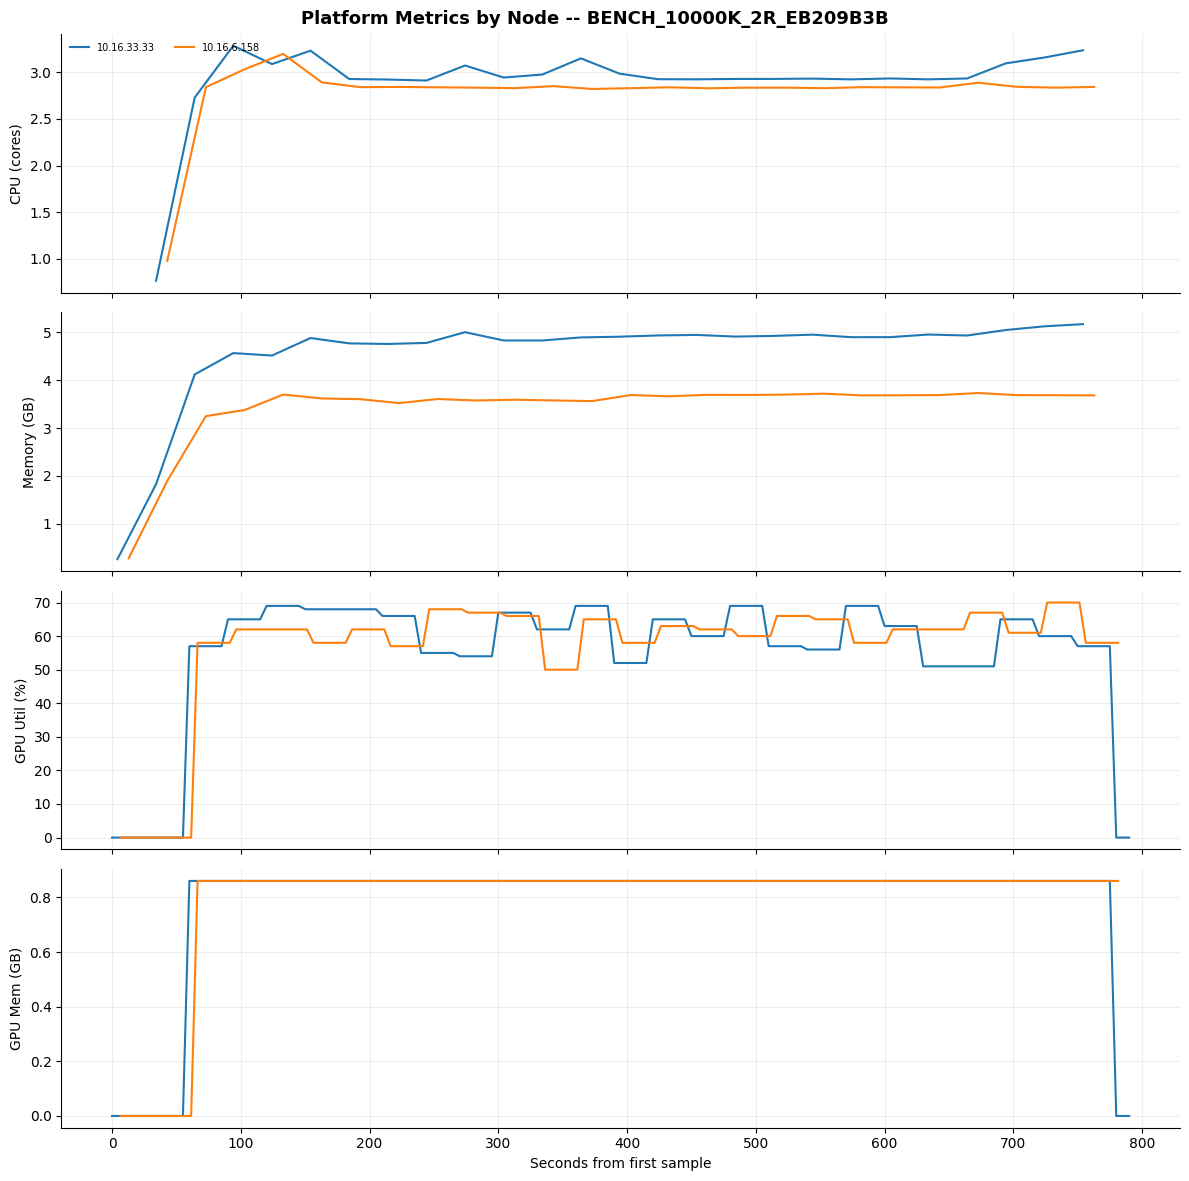

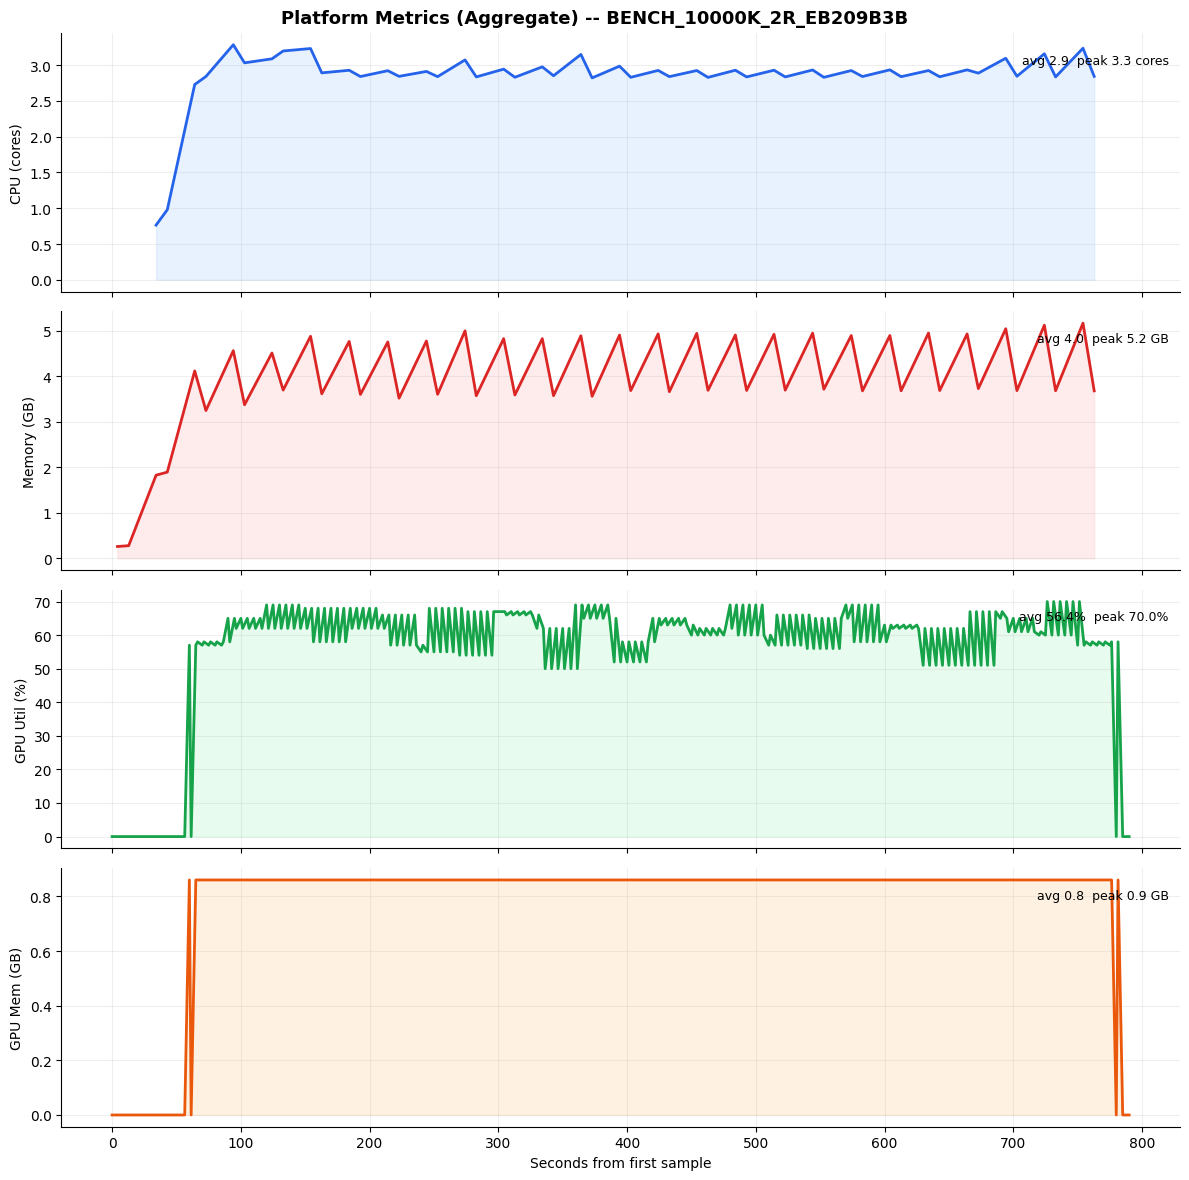


=== Summary ===


,run,job_name,status,wall_s,server_s,throughput,avg_cpu,max_cpu,avg_mem_gb,max_mem_gb,avg_gpu_util_pct,max_gpu_util_pct,avg_gpu_mem_gb,max_gpu_mem_gb
0,1,BENCH_10000K_2R_EB209B3B,DONE,803.69,791.87,12628,2.85,3.28,4.0,5.17,56.42,70.0,0.79,0.86


In [9]:
from collections import defaultdict
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd

BYTES_PER_GB = 1024 ** 3
PLATFORM_METRIC_NAMES = (
    "container.cpu.usage",
    "container.memory.usage",
    "container.gpu.utilization",
    "container.gpu.memory.usage",
)


def fetch_platform_metrics(session, event_table, job_name, created_time, completed_time):
    """Query event table for per-node CPU, memory, GPU, and GPU memory timeseries."""
    query = f"""
        SELECT
            TIMESTAMP,
            RECORD:metric.name::STRING AS metric_name,
            CAST(VALUE AS FLOAT) AS metric_value,
            COALESCE(RESOURCE_ATTRIBUTES:"snow.compute_pool.node.id"::STRING, 'unknown') AS node_id
        FROM {event_table}
        WHERE RESOURCE_ATTRIBUTES:"snow.service.name" = '{job_name}'
          AND SCOPE:"name" = 'snow.spcs.platform'
          AND RECORD_TYPE = 'METRIC'
          AND RECORD:metric.name IN ('container.cpu.usage', 'container.memory.usage', 'container.gpu.utilization', 'container.gpu.memory.usage')
          AND TIMESTAMP >= CONVERT_TIMEZONE('UTC', '{created_time}'::TIMESTAMP_LTZ)::TIMESTAMP_NTZ
          AND TIMESTAMP <= DATEADD(minute, 5, CONVERT_TIMEZONE('UTC', '{completed_time}'::TIMESTAMP_LTZ)::TIMESTAMP_NTZ)
        ORDER BY TIMESTAMP, node_id, metric_name
    """
    rows = session.sql(query).collect()
    if not rows:
        print(f"  [{job_name}] No platform metrics yet, retrying in 15s...")
        time.sleep(15)
        rows = session.sql(query).collect()
    if not rows:
        print(f"  [{job_name}] No platform metrics found.")
        return None

    raw_by_node = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    raw_cluster = defaultdict(lambda: defaultdict(list))

    for row in rows:
        rd = row.as_dict()
        ts = str(rd.get("TIMESTAMP", rd.get("timestamp")))
        name = rd.get("METRIC_NAME", rd.get("metric_name"))
        raw_value = rd.get("METRIC_VALUE", rd.get("metric_value"))
        node_id = str(rd.get("NODE_ID", rd.get("node_id", "unknown")))
        if raw_value is None or name not in PLATFORM_METRIC_NAMES:
            continue
        value = float(raw_value)
        raw_by_node[node_id][name][ts].append(value)
        raw_cluster[name][ts].append(value)

    def reduce_samples(name, samples):
        if name == "container.gpu.utilization":
            return float(sum(samples) / len(samples)) if samples else 0.0
        return float(sum(samples))

    def display_value(name, raw):
        if name in {"container.memory.usage", "container.gpu.memory.usage"}:
            return raw / BYTES_PER_GB
        if name == "container.gpu.utilization":
            return raw * 100.0
        return raw

    reduced_by_node = defaultdict(lambda: defaultdict(dict))
    reduced_cluster = defaultdict(dict)

    for node_id, metric_map in raw_by_node.items():
        for name, ts_map in metric_map.items():
            for ts, samples in ts_map.items():
                reduced_by_node[node_id][name][ts] = reduce_samples(name, samples)

    for name, ts_map in raw_cluster.items():
        for ts, samples in ts_map.items():
            reduced_cluster[name][ts] = reduce_samples(name, samples)

    node_data = {}
    for node_id, metric_map in sorted(reduced_by_node.items()):
        node_data[node_id] = {}
        for name, ts_map in metric_map.items():
            node_data[node_id][name] = [
                {"timestamp": ts, "value": display_value(name, raw)}
                for ts, raw in sorted(ts_map.items())
            ]

    cluster_data = {}
    for name, ts_map in reduced_cluster.items():
        cluster_data[name] = [
            {"timestamp": ts, "value": display_value(name, raw)}
            for ts, raw in sorted(ts_map.items())
        ]

    return {
        "node_data": node_data,
        "cluster_data": cluster_data,
        "data_points": len({ts for metric_map in reduced_cluster.values() for ts in metric_map}),
    }


def relative_seconds(points, origin=None):
    if not points:
        return [], []
    timestamps = [datetime.fromisoformat(p["timestamp"]) for p in points]
    base = origin or timestamps[0]
    return [(ts - base).total_seconds() for ts in timestamps], [p["value"] for p in points]


def find_origin(*series_list):
    timestamps = [
        datetime.fromisoformat(s[0]["timestamp"])
        for s in series_list if s and s[0].get("timestamp")
    ]
    return min(timestamps) if timestamps else None


def series_stats(points):
    values = [p["value"] for p in points]
    if not values:
        return None, None
    return sum(values) / len(values), max(values)


def format_stat(value, suffix=""):
    if value is None:
        return "-"
    return f"{value:.1f}{suffix}"


def plot_or_placeholder(ax, series, origin, *, color=None, fill_color=None, empty_message=None):
    if series:
        t, v = relative_seconds(series, origin)
        ax.plot(t, v, color=color, linewidth=2, label=None)
        if fill_color:
            ax.fill_between(t, v, color=fill_color, alpha=0.35)
        return True
    if empty_message:
        ax.text(0.5, 0.5, empty_message, transform=ax.transAxes, ha="center", va="center", color="#6b7280")
    return False


def plot_per_node(metrics, job_name):
    node_data = metrics["node_data"]
    all_series = [series for metric_map in node_data.values() for series in metric_map.values()]
    origin = find_origin(*all_series)

    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
    ax_cpu, ax_mem, ax_gpu, ax_gpu_mem = axes
    fig.suptitle(f"Platform Metrics by Node -- {job_name}", fontsize=13, fontweight="bold")

    has_cpu, has_mem, has_gpu, has_gpu_mem = False, False, False, False

    for node_id in sorted(node_data):
        cpu_series = node_data[node_id].get("container.cpu.usage", [])
        if cpu_series:
            t, v = relative_seconds(cpu_series, origin)
            ax_cpu.plot(t, v, linewidth=1.5, label=node_id)
            has_cpu = True

        mem_series = node_data[node_id].get("container.memory.usage", [])
        if mem_series:
            t, v = relative_seconds(mem_series, origin)
            ax_mem.plot(t, v, linewidth=1.5, label=node_id)
            has_mem = True

        gpu_series = node_data[node_id].get("container.gpu.utilization", [])
        if gpu_series:
            t, v = relative_seconds(gpu_series, origin)
            ax_gpu.plot(t, v, linewidth=1.5, label=node_id)
            has_gpu = True

        gpu_mem_series = node_data[node_id].get("container.gpu.memory.usage", [])
        if gpu_mem_series:
            t, v = relative_seconds(gpu_mem_series, origin)
            ax_gpu_mem.plot(t, v, linewidth=1.5, label=node_id)
            has_gpu_mem = True

    if not has_cpu:
        ax_cpu.text(0.5, 0.5, "No CPU samples", transform=ax_cpu.transAxes, ha="center", va="center", color="#6b7280")
    if not has_mem:
        ax_mem.text(0.5, 0.5, "No memory samples", transform=ax_mem.transAxes, ha="center", va="center", color="#6b7280")
    if not has_gpu:
        ax_gpu.text(0.5, 0.5, "No GPU util samples", transform=ax_gpu.transAxes, ha="center", va="center", color="#6b7280")
    if not has_gpu_mem:
        ax_gpu_mem.text(0.5, 0.5, "No GPU memory samples", transform=ax_gpu_mem.transAxes, ha="center", va="center", color="#6b7280")

    ax_cpu.set_ylabel("CPU (cores)")
    ax_mem.set_ylabel("Memory (GB)")
    ax_gpu.set_ylabel("GPU Util (%)")
    ax_gpu_mem.set_ylabel("GPU Mem (GB)")
    ax_gpu_mem.set_xlabel("Seconds from first sample")

    for ax in axes:
        ax.grid(True, alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    handles, labels = ax_cpu.get_legend_handles_labels()
    if handles:
        ax_cpu.legend(handles, labels, loc="upper left", fontsize=7, ncol=2, frameon=False)

    fig.tight_layout()
    plt.show()


def plot_aggregate(metrics, job_name):
    cluster_data = metrics["cluster_data"]
    cpu_series = cluster_data.get("container.cpu.usage", [])
    mem_series = cluster_data.get("container.memory.usage", [])
    gpu_series = cluster_data.get("container.gpu.utilization", [])
    gpu_mem_series = cluster_data.get("container.gpu.memory.usage", [])
    origin = find_origin(cpu_series, mem_series, gpu_series, gpu_mem_series)

    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
    ax_cpu, ax_mem, ax_gpu, ax_gpu_mem = axes
    fig.suptitle(f"Platform Metrics (Aggregate) -- {job_name}", fontsize=13, fontweight="bold")

    if plot_or_placeholder(ax_cpu, cpu_series, origin, color="#2563eb", fill_color="#bfdbfe", empty_message="No CPU samples"):
        avg_cpu, max_cpu = series_stats(cpu_series)
        ax_cpu.text(0.99, 0.92, f"avg {avg_cpu:.1f}  peak {max_cpu:.1f} cores",
                    transform=ax_cpu.transAxes, ha="right", va="top", fontsize=9)

    if plot_or_placeholder(ax_mem, mem_series, origin, color="#dc2626", fill_color="#fecaca", empty_message="No memory samples"):
        avg_mem, max_mem = series_stats(mem_series)
        ax_mem.text(0.99, 0.92, f"avg {avg_mem:.1f}  peak {max_mem:.1f} GB",
                    transform=ax_mem.transAxes, ha="right", va="top", fontsize=9)

    if plot_or_placeholder(ax_gpu, gpu_series, origin, color="#16a34a", fill_color="#bbf7d0", empty_message="No GPU util samples"):
        avg_gpu, max_gpu = series_stats(gpu_series)
        ax_gpu.text(0.99, 0.92, f"avg {avg_gpu:.1f}%  peak {max_gpu:.1f}%",
                    transform=ax_gpu.transAxes, ha="right", va="top", fontsize=9)

    if plot_or_placeholder(ax_gpu_mem, gpu_mem_series, origin, color="#ea580c", fill_color="#fed7aa", empty_message="No GPU memory samples"):
        avg_gpu_mem, max_gpu_mem = series_stats(gpu_mem_series)
        ax_gpu_mem.text(0.99, 0.92, f"avg {avg_gpu_mem:.1f}  peak {max_gpu_mem:.1f} GB",
                        transform=ax_gpu_mem.transAxes, ha="right", va="top", fontsize=9)

    ax_cpu.set_ylabel("CPU (cores)")
    ax_mem.set_ylabel("Memory (GB)")
    ax_gpu.set_ylabel("GPU Util (%)")
    ax_gpu_mem.set_ylabel("GPU Mem (GB)")
    ax_gpu_mem.set_xlabel("Seconds from first sample")

    for ax in axes:
        ax.grid(True, alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()
    plt.show()


# --- Collect metrics and plot for each run ---
for r in results:
    if EVENT_TABLE is None:
        print("Platform metrics skipped (EVENT_TABLE not configured).")
        break
    if not r.get("created_time") or not r.get("completed_time"):
        print(f"Run {r['run']}: no timing data, skipping metrics.")
        continue

    print(f"\n--- Run {r['run']}: {r['job_name']} ---")
    metrics = fetch_platform_metrics(
        session, EVENT_TABLE, r["job_name"], r["created_time"], r["completed_time"],
    )

    if metrics:
        cluster_cpu = metrics["cluster_data"].get("container.cpu.usage", [])
        cluster_mem = metrics["cluster_data"].get("container.memory.usage", [])
        cluster_gpu = metrics["cluster_data"].get("container.gpu.utilization", [])
        cluster_gpu_mem = metrics["cluster_data"].get("container.gpu.memory.usage", [])

        cpu_values = [p["value"] for p in cluster_cpu]
        mem_values = [p["value"] for p in cluster_mem]
        gpu_values = [p["value"] for p in cluster_gpu]
        gpu_mem_values = [p["value"] for p in cluster_gpu_mem]

        r["avg_cpu"] = round(sum(cpu_values) / len(cpu_values), 2) if cpu_values else None
        r["max_cpu"] = round(max(cpu_values), 2) if cpu_values else None
        r["avg_mem_gb"] = round(sum(mem_values) / len(mem_values), 2) if mem_values else None
        r["max_mem_gb"] = round(max(mem_values), 2) if mem_values else None
        r["avg_gpu_util_pct"] = round(sum(gpu_values) / len(gpu_values), 2) if gpu_values else None
        r["max_gpu_util_pct"] = round(max(gpu_values), 2) if gpu_values else None
        r["avg_gpu_mem_gb"] = round(sum(gpu_mem_values) / len(gpu_mem_values), 2) if gpu_mem_values else None
        r["max_gpu_mem_gb"] = round(max(gpu_mem_values), 2) if gpu_mem_values else None

        print(
            f"  Platform: {metrics['data_points']} timestamp(s), "
            f"CPU avg={format_stat(r['avg_cpu'])}/max={format_stat(r['max_cpu'])} cores, "
            f"Mem avg={format_stat(r['avg_mem_gb'])}/max={format_stat(r['max_mem_gb'])} GB, "
            f"GPU avg={format_stat(r['avg_gpu_util_pct'], '%')}/max={format_stat(r['max_gpu_util_pct'], '%')}, "
            f"VRAM avg={format_stat(r['avg_gpu_mem_gb'])}/max={format_stat(r['max_gpu_mem_gb'])} GB"
        )

        plot_per_node(metrics, r["job_name"])
        plot_aggregate(metrics, r["job_name"])

# --- Summary table ---
print("\n=== Summary ===")
df = pd.DataFrame(results)
display_cols = [
    "run", "job_name", "status", "wall_s", "server_s",
    "throughput", "avg_cpu", "max_cpu", "avg_mem_gb", "max_mem_gb",
    "avg_gpu_util_pct", "max_gpu_util_pct", "avg_gpu_mem_gb", "max_gpu_mem_gb",
]
existing_cols = [c for c in display_cols if c in df.columns]
display(df[existing_cols])

## Cleanup

In [10]:
# session.sql(f"DROP COMPUTE POOL IF EXISTS {POOL_NAME}").collect()
# print(f"Pool {POOL_NAME} dropped.")